In [1]:
import os
import timm
import torch
import numpy as np

import utils.data as data_utils
from utils.predict import PredictPlants

random_seed = 8

/home/takayuki/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Model

In [2]:
timm_model_name = "convnextv2_tiny.fcmae_ft_in22k_in1k"

best_model_path = "/home/takayuki/Desktop/summer2025/plants/training/models/best_model_06-21_12-52--22_tiny28M_stratified_convnextv2_tiny.fcmae_ft_in22k_in1k.pth"
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Model file not found: {best_model_path}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    torch.cuda.manual_seed(random_seed)
    print("GPU: ", torch.cuda.get_device_name(0))
    
model = timm.create_model(timm_model_name, pretrained=False, num_classes=21)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

print(f"Model loaded from {best_model_path}")

Using device: cuda
GPU:  NVIDIA RTX A500 Laptop GPU
Model loaded from /home/takayuki/Desktop/summer2025/plants/training/models/best_model_06-21_12-52--22_tiny28M_stratified_convnextv2_tiny.fcmae_ft_in22k_in1k.pth


## Predictor

In [3]:
predictor = PredictPlants(timm_model_name, best_model_path, 21)

## Hands Dataset

Using the entire dataset as the test set. No train/val split.
Inspecting directory: /home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/hand_squared
Found 9 classes locally: ['Hydrocharis morsus-ranae', 'Myriophyllum spicatum', 'Nitellopsis obtusa', 'Nuphar variegata', 'Potamogeton crispus', 'Potamogeton gramineus', 'Potamogeton illinoensis', 'Potamogeton richardsonii', 'Ranunculus aquatilis']
Remapped 19 images to use canonical indices.
Total dataset size 	: 19
Calculated train size 	: 0
Calculated val size 	: 0
Calculated test size 	: 19

Test DataLoader created with 19 images from /home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/hand_squared.
Classnames 
Processing image with true label: Hydrocharis morsus-ranae, idx: 5
True label: tensor([5])


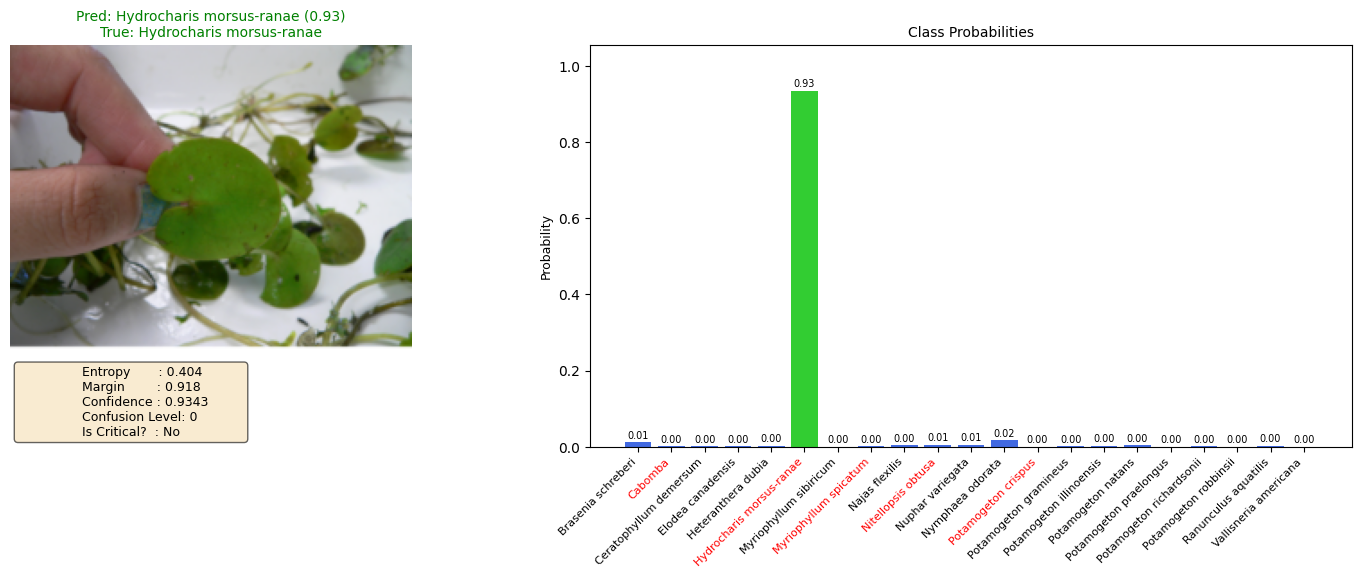


Prediction Summary:
+-----------------+--------------------------+--------------------------+--------------+
| Metric          | Value                    | Top-k Prediction         |   Confidence |
+=================+==========================+==========================+==============+
| Predicted Class | Hydrocharis morsus-ranae | Hydrocharis morsus-ranae |       0.9343 |
+-----------------+--------------------------+--------------------------+--------------+
| Confidence      | 0.9343                   | Nymphaea odorata         |       0.0168 |
+-----------------+--------------------------+--------------------------+--------------+
| Entropy         | 0.4044                   | Brasenia schreberi       |       0.0115 |
+-----------------+--------------------------+--------------------------+--------------+
| Margin          | 0.9175                   | Nuphar variegata         |       0.0059 |
+-----------------+--------------------------+--------------------------+--------------+


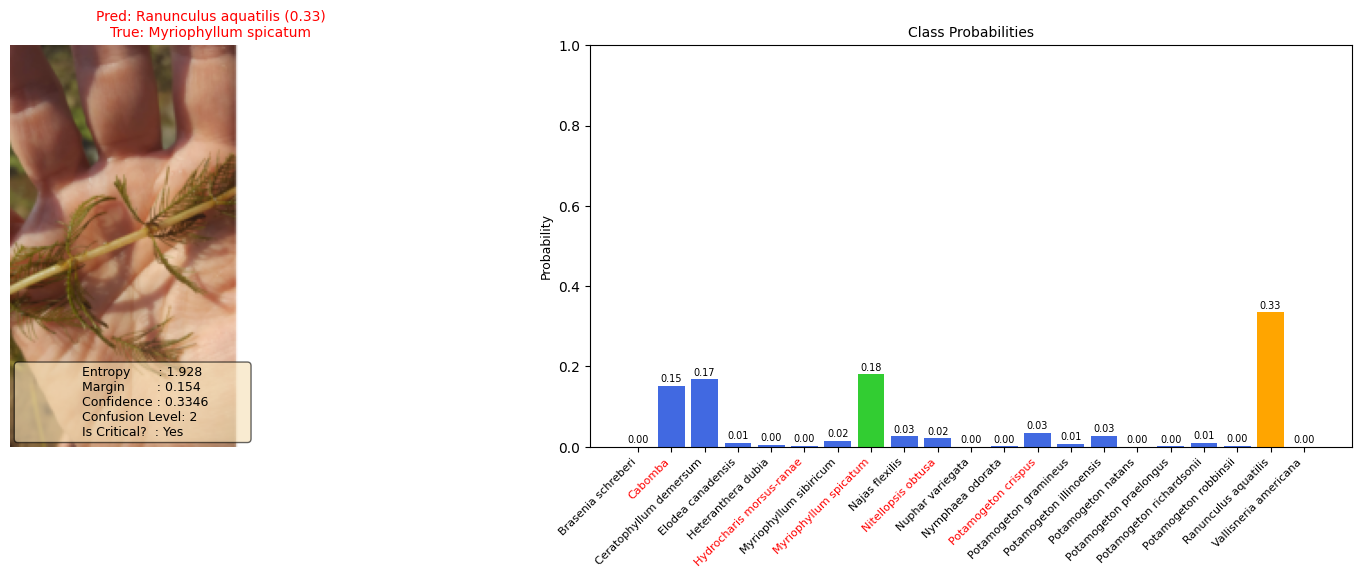


Prediction Summary:
+-----------------+----------------------+-------------------------+--------------+
| Metric          | Value                | Top-k Prediction        |   Confidence |
+=================+======================+=========================+==============+
| Predicted Class | Ranunculus aquatilis | Ranunculus aquatilis    |       0.3346 |
+-----------------+----------------------+-------------------------+--------------+
| Confidence      | 0.3346               | Myriophyllum spicatum   |       0.1805 |
+-----------------+----------------------+-------------------------+--------------+
| Entropy         | 1.9276               | Ceratophyllum demersum  |       0.1679 |
+-----------------+----------------------+-------------------------+--------------+
| Margin          | 0.1541               | Cabomba                 |       0.1521 |
+-----------------+----------------------+-------------------------+--------------+
| Is Correct?     | False                | Potamogeton 

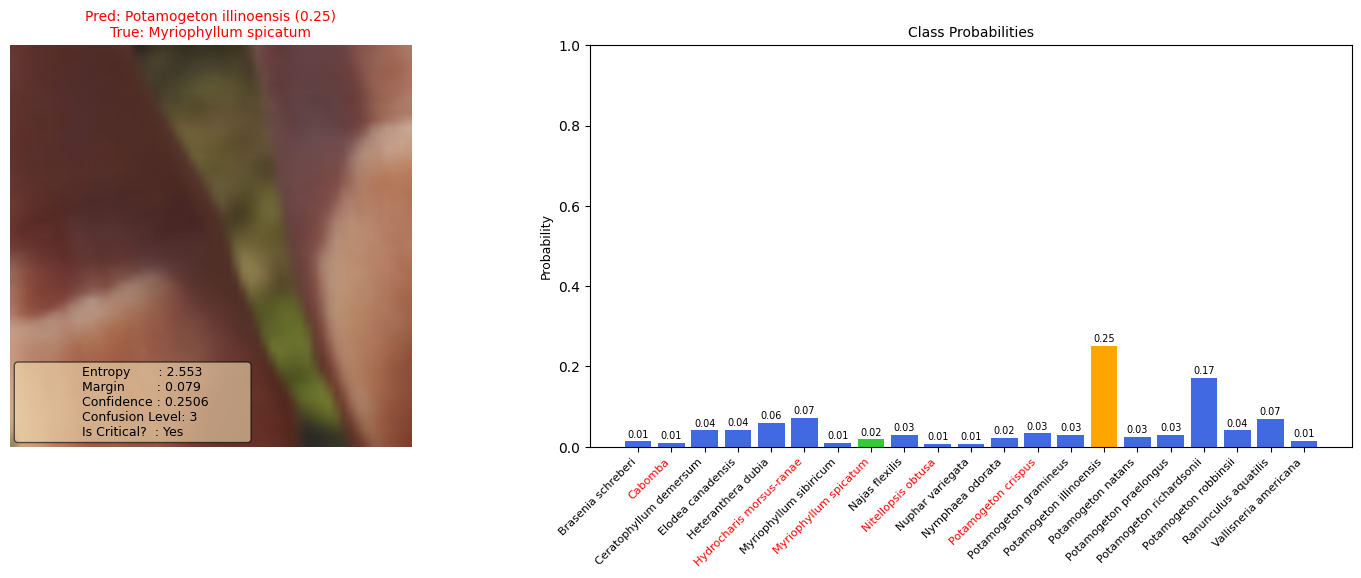


Prediction Summary:
+-----------------+-------------------------+--------------------------+--------------+
| Metric          | Value                   | Top-k Prediction         | Confidence   |
+=================+=========================+==========================+==============+
| Predicted Class | Potamogeton illinoensis | Potamogeton illinoensis  | 0.2506       |
+-----------------+-------------------------+--------------------------+--------------+
| Confidence      | 0.2506                  | Potamogeton richardsonii | 0.1718       |
+-----------------+-------------------------+--------------------------+--------------+
| Entropy         | 2.5530                  | Hydrocharis morsus-ranae | 0.0720       |
+-----------------+-------------------------+--------------------------+--------------+
| Margin          | 0.0788                  | Ranunculus aquatilis     | 0.0695       |
+-----------------+-------------------------+--------------------------+--------------+
| Is Correc

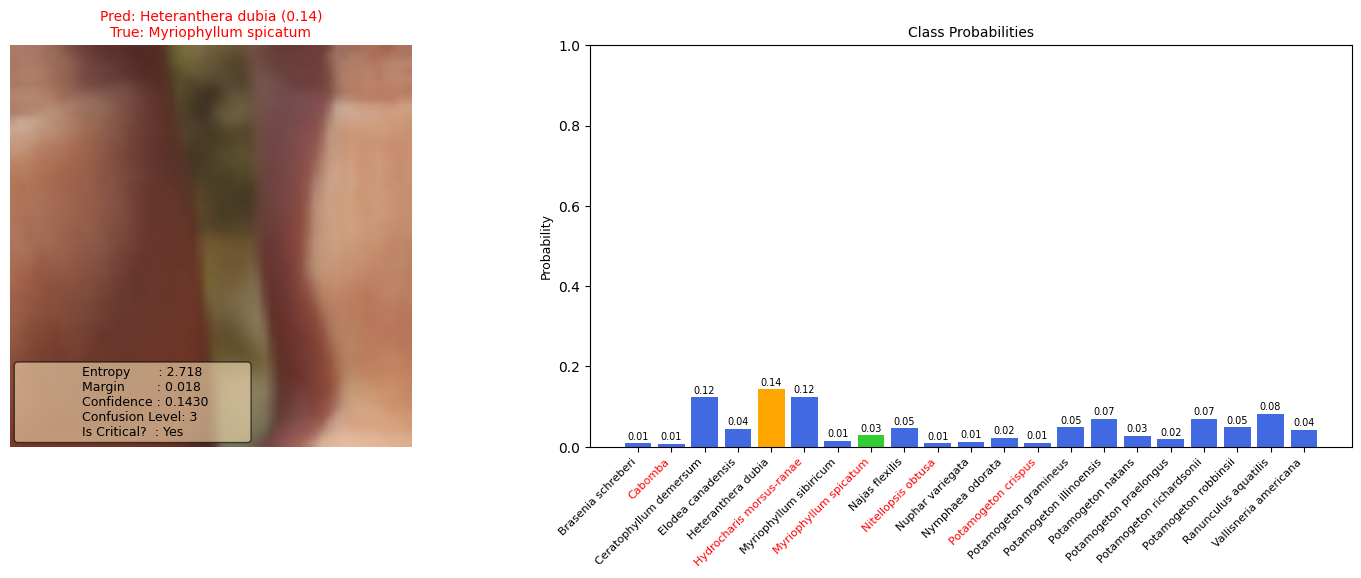


Prediction Summary:
+-----------------+--------------------+--------------------------+--------------+
| Metric          | Value              | Top-k Prediction         | Confidence   |
+=================+====================+==========================+==============+
| Predicted Class | Heteranthera dubia | Heteranthera dubia       | 0.1430       |
+-----------------+--------------------+--------------------------+--------------+
| Confidence      | 0.1430             | Hydrocharis morsus-ranae | 0.1249       |
+-----------------+--------------------+--------------------------+--------------+
| Entropy         | 2.7175             | Ceratophyllum demersum   | 0.1233       |
+-----------------+--------------------+--------------------------+--------------+
| Margin          | 0.0180             | Ranunculus aquatilis     | 0.0821       |
+-----------------+--------------------+--------------------------+--------------+
| Is Correct?     | False              | Potamogeton illinoensis  

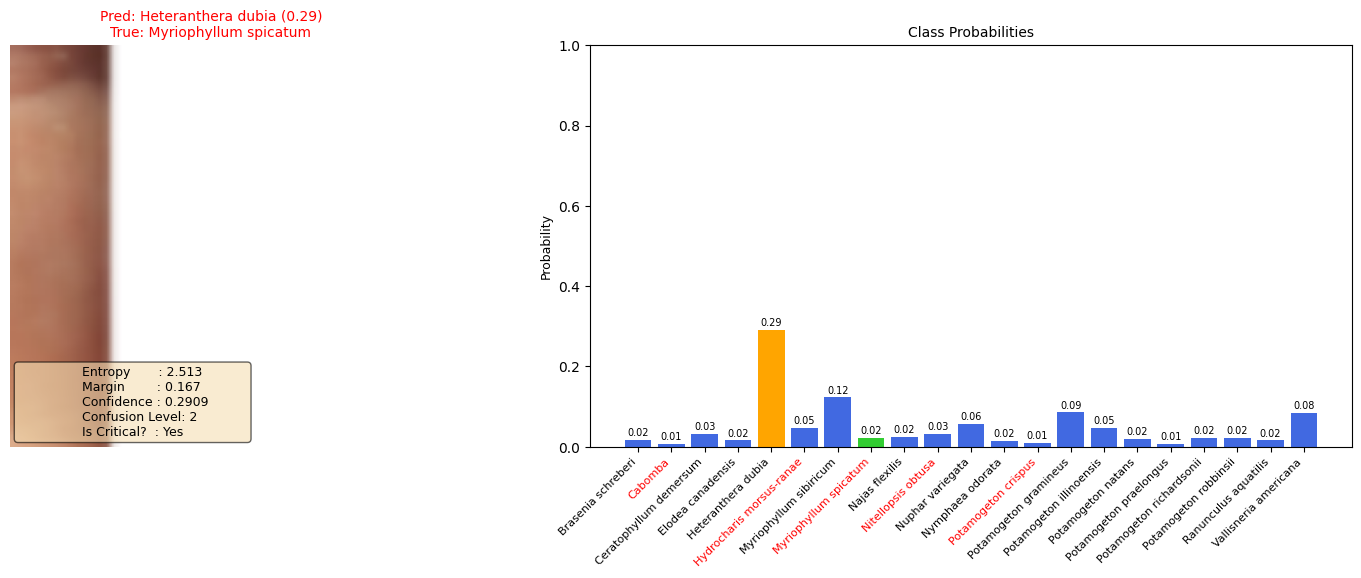


Prediction Summary:
+-----------------+--------------------+------------------------+--------------+
| Metric          | Value              | Top-k Prediction       | Confidence   |
+=================+====================+========================+==============+
| Predicted Class | Heteranthera dubia | Heteranthera dubia     | 0.2909       |
+-----------------+--------------------+------------------------+--------------+
| Confidence      | 0.2909             | Myriophyllum sibiricum | 0.1234       |
+-----------------+--------------------+------------------------+--------------+
| Entropy         | 2.5134             | Potamogeton gramineus  | 0.0859       |
+-----------------+--------------------+------------------------+--------------+
| Margin          | 0.1674             | Vallisneria americana  | 0.0844       |
+-----------------+--------------------+------------------------+--------------+
| Is Correct?     | False              | Nuphar variegata       | 0.0572       |
+------

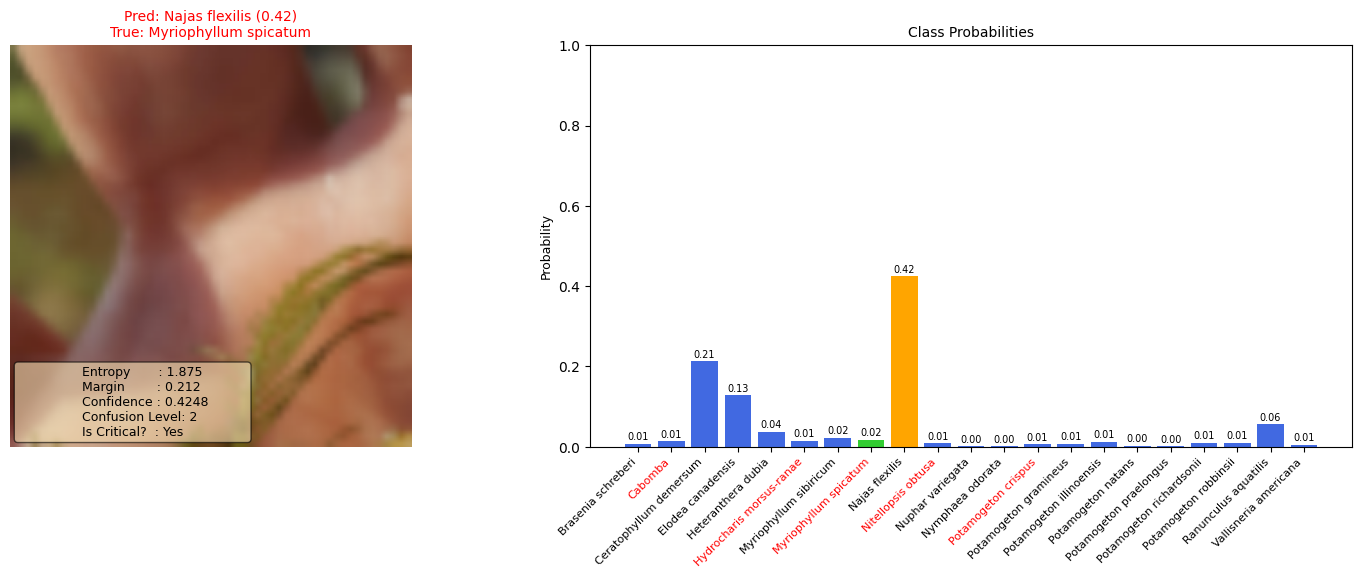


Prediction Summary:
+-----------------+----------------+------------------------+--------------+
| Metric          | Value          | Top-k Prediction       | Confidence   |
+=================+================+========================+==============+
| Predicted Class | Najas flexilis | Najas flexilis         | 0.4248       |
+-----------------+----------------+------------------------+--------------+
| Confidence      | 0.4248         | Ceratophyllum demersum | 0.2126       |
+-----------------+----------------+------------------------+--------------+
| Entropy         | 1.8754         | Elodea canadensis      | 0.1280       |
+-----------------+----------------+------------------------+--------------+
| Margin          | 0.2123         | Ranunculus aquatilis   | 0.0561       |
+-----------------+----------------+------------------------+--------------+
| Is Correct?     | False          | Heteranthera dubia     | 0.0367       |
+-----------------+----------------+-------------------

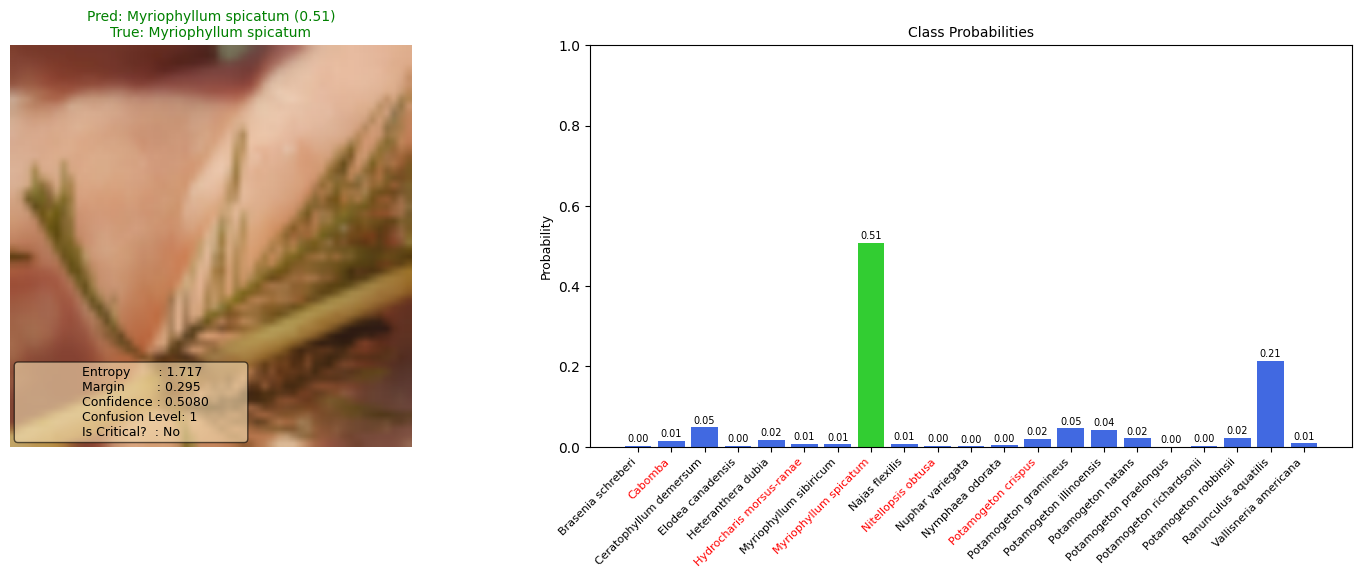


Prediction Summary:
+-----------------+-----------------------+-------------------------+--------------+
| Metric          | Value                 | Top-k Prediction        | Confidence   |
+=================+=======================+=========================+==============+
| Predicted Class | Myriophyllum spicatum | Myriophyllum spicatum   | 0.5080       |
+-----------------+-----------------------+-------------------------+--------------+
| Confidence      | 0.5080                | Ranunculus aquatilis    | 0.2134       |
+-----------------+-----------------------+-------------------------+--------------+
| Entropy         | 1.7165                | Ceratophyllum demersum  | 0.0482       |
+-----------------+-----------------------+-------------------------+--------------+
| Margin          | 0.2945                | Potamogeton gramineus   | 0.0458       |
+-----------------+-----------------------+-------------------------+--------------+
| Is Correct?     | True                  | 

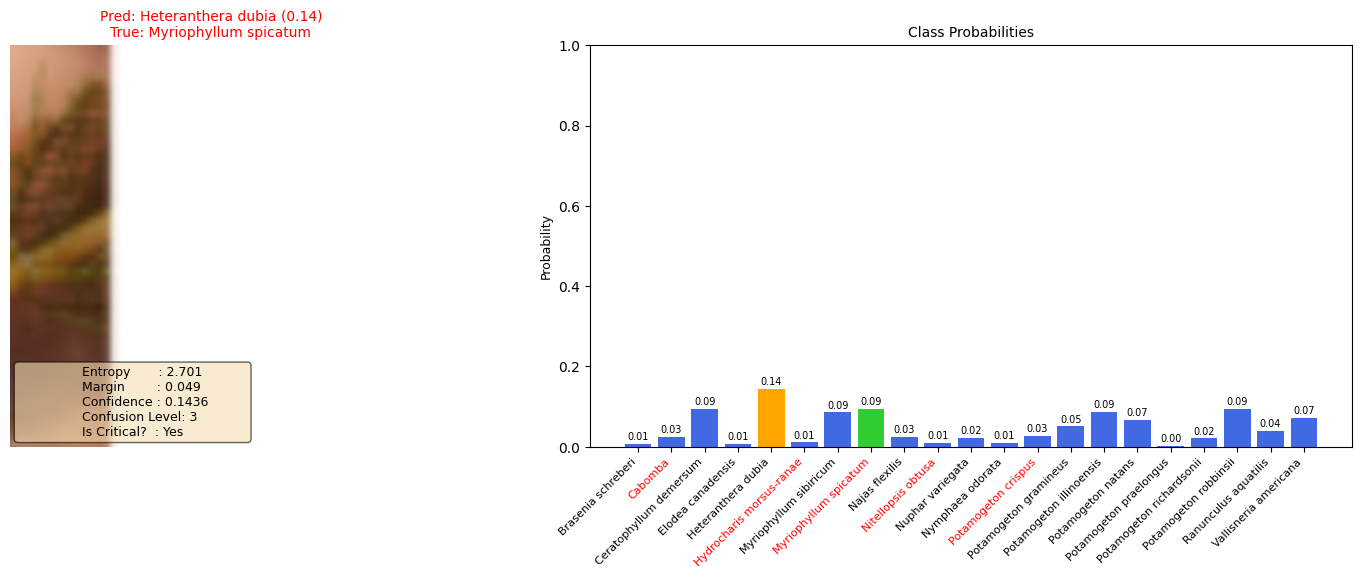


Prediction Summary:
+-----------------+--------------------+-------------------------+--------------+
| Metric          | Value              | Top-k Prediction        | Confidence   |
+=================+====================+=========================+==============+
| Predicted Class | Heteranthera dubia | Heteranthera dubia      | 0.1436       |
+-----------------+--------------------+-------------------------+--------------+
| Confidence      | 0.1436             | Ceratophyllum demersum  | 0.0949       |
+-----------------+--------------------+-------------------------+--------------+
| Entropy         | 2.7005             | Myriophyllum spicatum   | 0.0946       |
+-----------------+--------------------+-------------------------+--------------+
| Margin          | 0.0488             | Potamogeton robbinsii   | 0.0938       |
+-----------------+--------------------+-------------------------+--------------+
| Is Correct?     | False              | Potamogeton illinoensis | 0.0875    

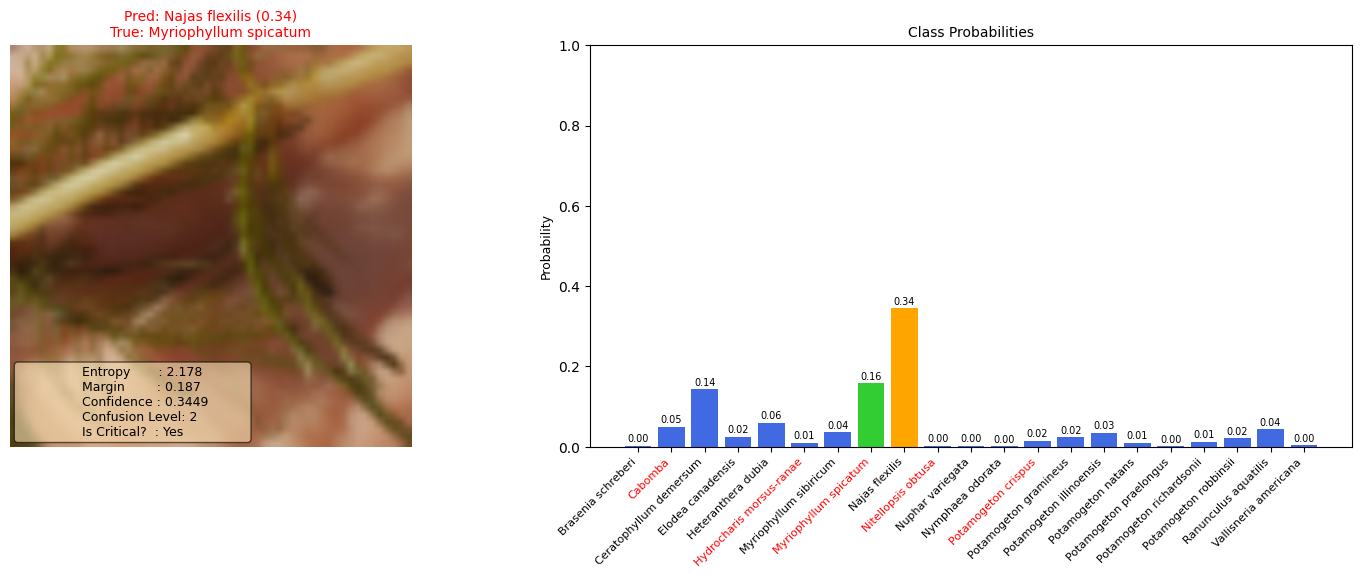


Prediction Summary:
+-----------------+----------------+------------------------+--------------+
| Metric          | Value          | Top-k Prediction       | Confidence   |
+=================+================+========================+==============+
| Predicted Class | Najas flexilis | Najas flexilis         | 0.3449       |
+-----------------+----------------+------------------------+--------------+
| Confidence      | 0.3449         | Myriophyllum spicatum  | 0.1579       |
+-----------------+----------------+------------------------+--------------+
| Entropy         | 2.1779         | Ceratophyllum demersum | 0.1434       |
+-----------------+----------------+------------------------+--------------+
| Margin          | 0.1871         | Heteranthera dubia     | 0.0601       |
+-----------------+----------------+------------------------+--------------+
| Is Correct?     | False          | Cabomba                | 0.0496       |
+-----------------+----------------+-------------------

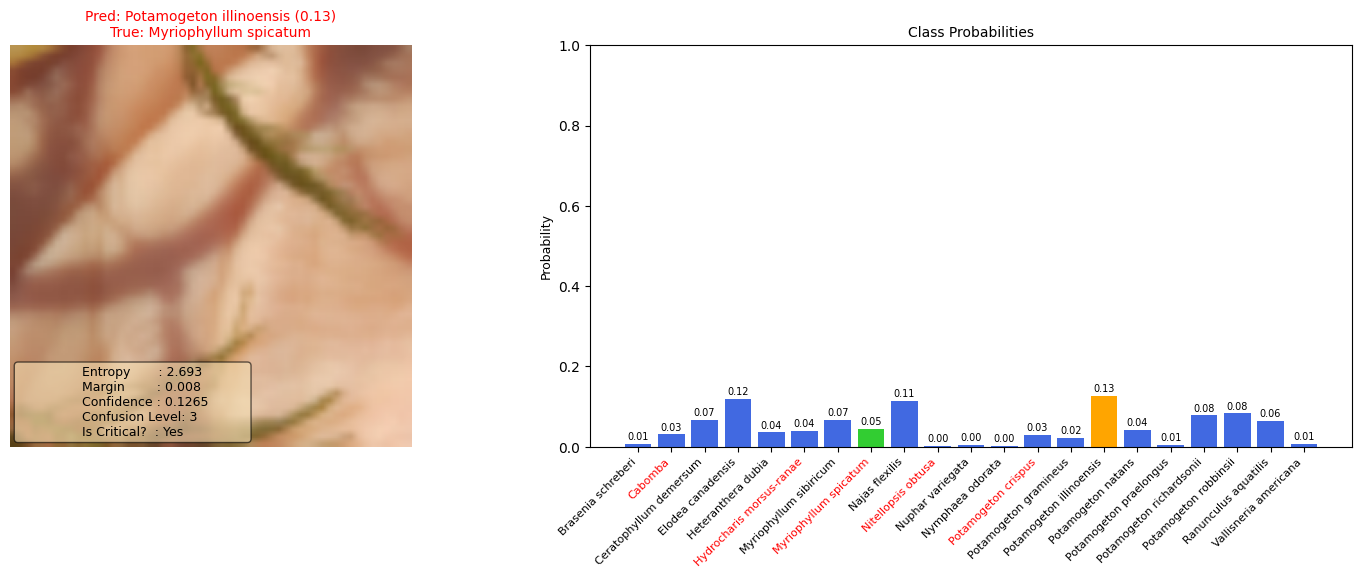


Prediction Summary:
+-----------------+-------------------------+--------------------------+--------------+
| Metric          | Value                   | Top-k Prediction         | Confidence   |
+=================+=========================+==========================+==============+
| Predicted Class | Potamogeton illinoensis | Potamogeton illinoensis  | 0.1265       |
+-----------------+-------------------------+--------------------------+--------------+
| Confidence      | 0.1265                  | Elodea canadensis        | 0.1188       |
+-----------------+-------------------------+--------------------------+--------------+
| Entropy         | 2.6932                  | Najas flexilis           | 0.1149       |
+-----------------+-------------------------+--------------------------+--------------+
| Margin          | 0.0077                  | Potamogeton robbinsii    | 0.0833       |
+-----------------+-------------------------+--------------------------+--------------+
| Is Correc

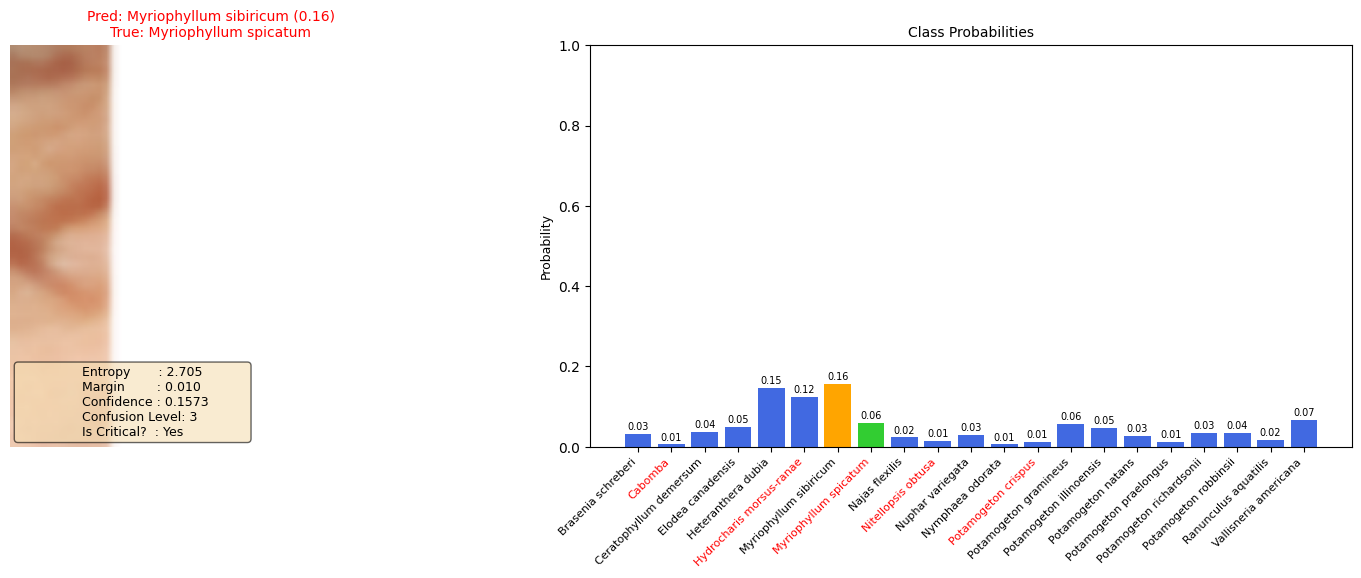


Prediction Summary:
+-----------------+------------------------+--------------------------+--------------+
| Metric          | Value                  | Top-k Prediction         | Confidence   |
+=================+========================+==========================+==============+
| Predicted Class | Myriophyllum sibiricum | Myriophyllum sibiricum   | 0.1573       |
+-----------------+------------------------+--------------------------+--------------+
| Confidence      | 0.1573                 | Heteranthera dubia       | 0.1472       |
+-----------------+------------------------+--------------------------+--------------+
| Entropy         | 2.7052                 | Hydrocharis morsus-ranae | 0.1241       |
+-----------------+------------------------+--------------------------+--------------+
| Margin          | 0.0101                 | Vallisneria americana    | 0.0671       |
+-----------------+------------------------+--------------------------+--------------+
| Is Correct?     | Fa

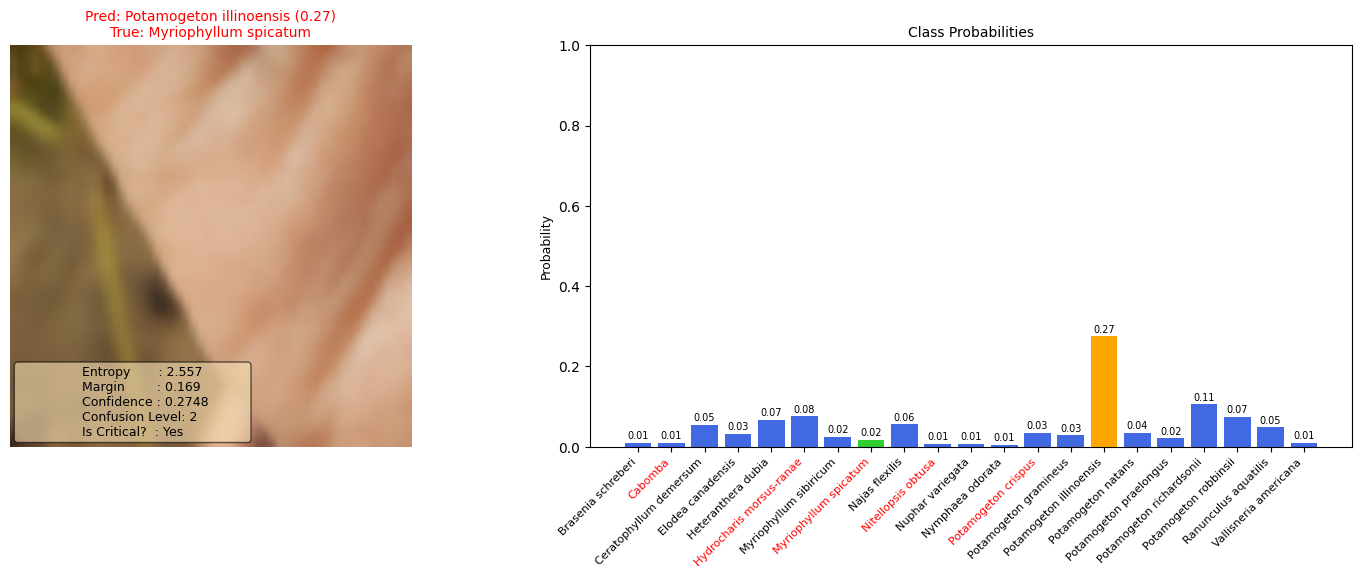


Prediction Summary:
+-----------------+-------------------------+--------------------------+--------------+
| Metric          | Value                   | Top-k Prediction         | Confidence   |
+=================+=========================+==========================+==============+
| Predicted Class | Potamogeton illinoensis | Potamogeton illinoensis  | 0.2748       |
+-----------------+-------------------------+--------------------------+--------------+
| Confidence      | 0.2748                  | Potamogeton richardsonii | 0.1059       |
+-----------------+-------------------------+--------------------------+--------------+
| Entropy         | 2.5568                  | Hydrocharis morsus-ranae | 0.0761       |
+-----------------+-------------------------+--------------------------+--------------+
| Margin          | 0.1689                  | Potamogeton robbinsii    | 0.0746       |
+-----------------+-------------------------+--------------------------+--------------+
| Is Correc

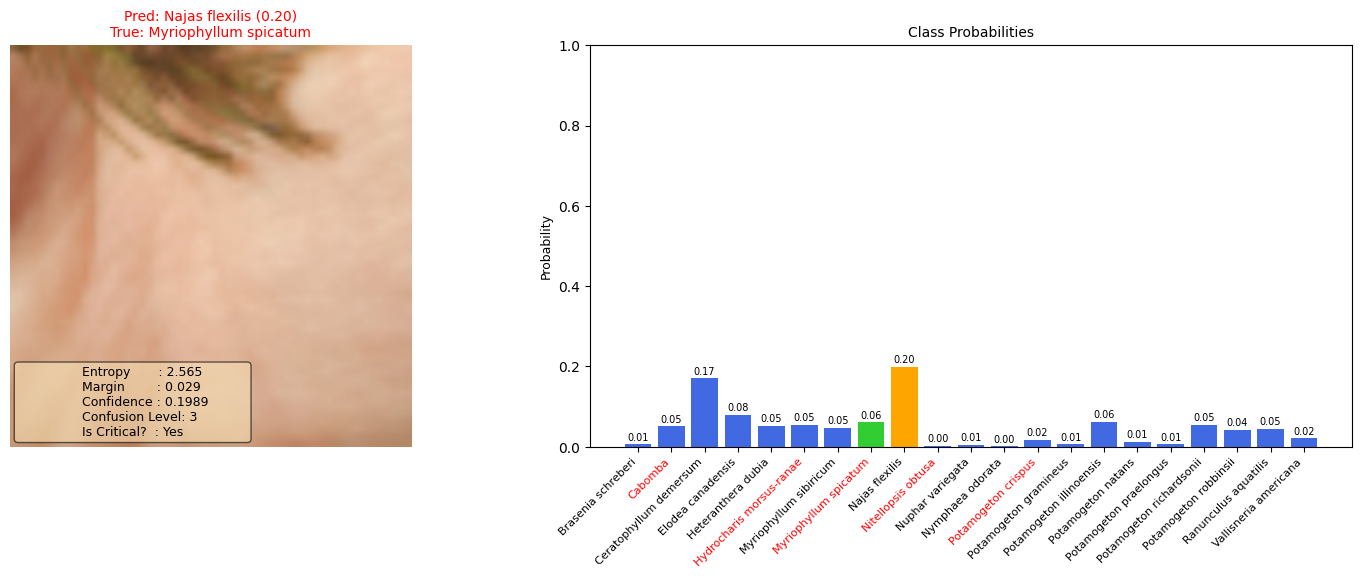


Prediction Summary:
+-----------------+----------------+-------------------------+--------------+
| Metric          | Value          | Top-k Prediction        | Confidence   |
+=================+================+=========================+==============+
| Predicted Class | Najas flexilis | Najas flexilis          | 0.1989       |
+-----------------+----------------+-------------------------+--------------+
| Confidence      | 0.1989         | Ceratophyllum demersum  | 0.1703       |
+-----------------+----------------+-------------------------+--------------+
| Entropy         | 2.5655         | Elodea canadensis       | 0.0800       |
+-----------------+----------------+-------------------------+--------------+
| Margin          | 0.0286         | Potamogeton illinoensis | 0.0622       |
+-----------------+----------------+-------------------------+--------------+
| Is Correct?     | False          | Myriophyllum spicatum   | 0.0610       |
+-----------------+----------------+-------

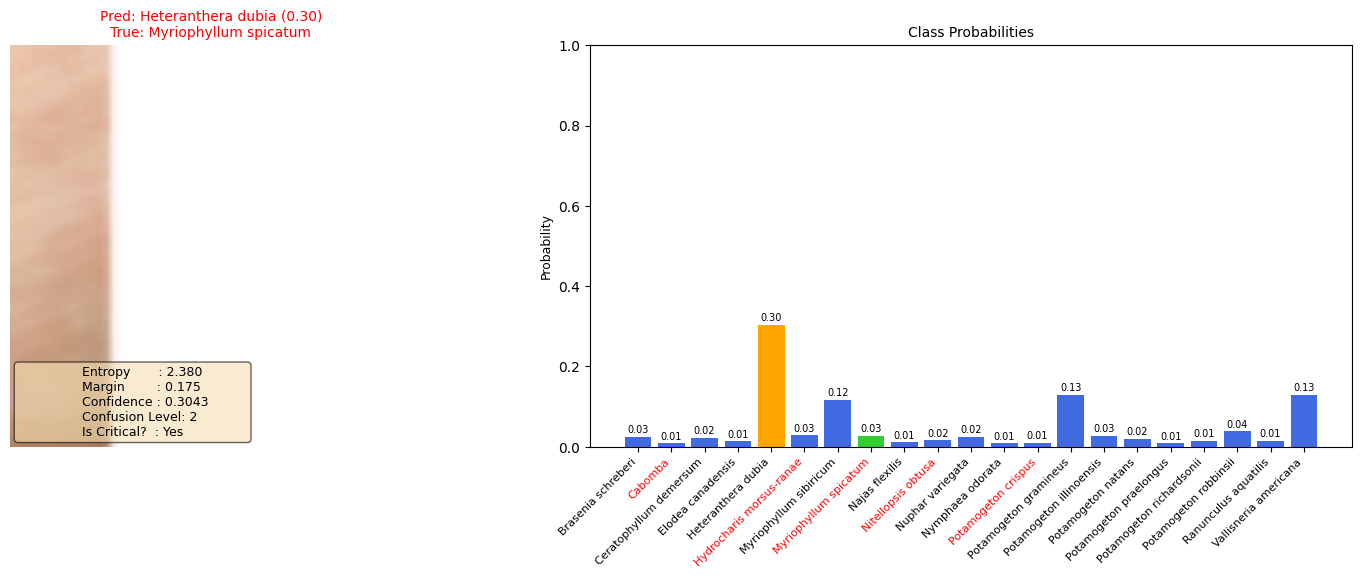


Prediction Summary:
+-----------------+--------------------+------------------------+--------------+
| Metric          | Value              | Top-k Prediction       | Confidence   |
+=================+====================+========================+==============+
| Predicted Class | Heteranthera dubia | Heteranthera dubia     | 0.3043       |
+-----------------+--------------------+------------------------+--------------+
| Confidence      | 0.3043             | Potamogeton gramineus  | 0.1294       |
+-----------------+--------------------+------------------------+--------------+
| Entropy         | 2.3797             | Vallisneria americana  | 0.1289       |
+-----------------+--------------------+------------------------+--------------+
| Margin          | 0.1749             | Myriophyllum sibiricum | 0.1178       |
+-----------------+--------------------+------------------------+--------------+
| Is Correct?     | False              | Potamogeton robbinsii  | 0.0387       |
+------

In [4]:
hand_dataloader = data_utils.get_test_dataloader()
results = predictor.predict_on_dataloader(hand_dataloader, num_preds=2, k = 8)

## Patch and Predict